In [ ]:
Simo Xiang
Brandon Caceres
Bryan Herrera
Mdhasib Uddin

In this section, we created a new dataset to analyze the affordability of childcare across New York City’s five boroughs. 

We first defined a dictionary named affordability containing estimated childcare rates for each borough, including the average daily rate and the corresponding annual rate. Next, we merged this DataFrame with the income dataset obtained from data preparation part. The merging process was performed using the pandas.merge() function on the common key “Borough”. Then we created a new column called “Affordability_Ratio”, which calculates the proportion of annual childcare cost relative to median household income

This affordability ratio provides an intuitive measure of the financial burden childcare expenses impose on families in each borough as a higher ratio indicates that childcare consumes a larger portion of household income, suggesting reduced affordability.

In [9]:
import pandas

# The dataset from data preparation part

income = pandas.read_csv('/Users/mdfurm/Downloads/nyc_childcare_data.csv')
print(income.head())

         Borough  Median_Household_Income  Children_Under_6
0          Bronx                  46838.0            171572
1       Brooklyn                  76912.0            302879
2      Manhattan                 101078.0            120810
3         Queens                  81929.0            233100
4  Staten Island                  95543.0             54803


In [10]:
# Create summarized borough-level childcare fee data
rate = {
    "Borough": ["Bronx", "Brooklyn", "Queens", "Manhattan", "Staten Island"],
    "Average_Daily_Rate": [42, 46, 45, 52, 43],
    "Annual_Rate": [51100, 51100, 51100, 51100, 51100],
}

affordability = pandas.DataFrame(rate)

# Merge selected columns from two DataFrames
affordability = pandas.merge(
    affordability[['Borough', 'Annual_Rate']],
    income[['Borough', 'Median_Household_Income']],
    on='Borough',
    how='left'
)

# Create a new column for affordability ratio
affordability["Affordability_Ratio"] = (affordability["Annual_Rate"] / affordability["Median_Household_Income"]).round(2)

print(affordability.head())

         Borough  Annual_Rate  Median_Household_Income  Affordability_Ratio
0          Bronx        51100                  46838.0                 1.09
1       Brooklyn        51100                  76912.0                 0.66
2         Queens        51100                  81929.0                 0.62
3      Manhattan        51100                 101078.0                 0.51
4  Staten Island        51100                  95543.0                 0.53


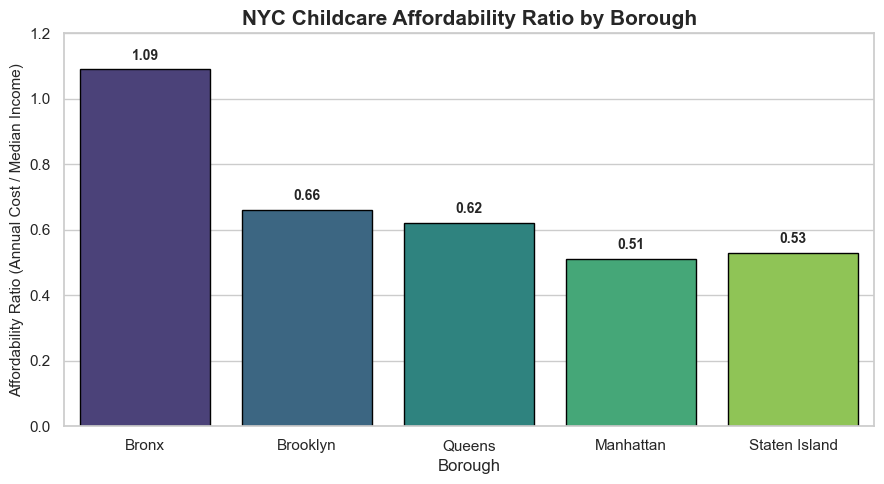

In [11]:
# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 5))
sns.barplot(
    data=affordability,
    x="Borough",
    y="Affordability_Ratio",
    hue="Borough",
    palette="viridis",
    legend=False,
    edgecolor="black"
)
plt.title("NYC Childcare Affordability Ratio by Borough", fontsize=15, weight="bold")
plt.xlabel("Borough", fontsize=12)
plt.ylabel("Affordability Ratio (Annual Cost / Median Income)", fontsize=11)
plt.ylim(0, 1.2)
for i, v in enumerate(affordability["Affordability_Ratio"]):
    plt.text(i, v + 0.03, f"{v:.2f}", ha="center", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.show()


In this section, we processed the Childcare Centers dataset obtained from NYC Open Data. The code cleans and analyzes a childcare dataset to calculate the total capacity of childcare centers by borough for easy comparison between boroughs and can help identify areas with limited childcare availability, supporting planning and decision making for resource allocation. 

The raw dataset was a CSV file that was imported and filtered to include only the relevant columns: “Borough” and “Maximum Capacity.” To ensure data integrity, rows with missing values in either column were removed using the dropna() function. The capacity values were then converted to numeric format with pandas.to_numeric() to prepare for aggregation.

Since the dataset contained borough names in uppercase letters, which differed from the format in the merging dataset, we standardized them for consistency. After cleaning, the dataset was grouped by borough using the groupby() function, and the total maximum capacity for each borough was calculated with the .sum() method.

From the results, we can observe that Queens and Brooklyn have the highest total childcare capacities, indicating a larger infrastructure for early childhood services. In contrast, Staten Island has the smallest capacity, which may suggest fewer childcare centers or lower demand in that area.

In [15]:
# dirty data from public data source
capacity = pandas.read_csv('/Users/mdfurm/Downloads/Childcare_Centers_20251012.csv')

# Keep only Borough and Capacity columns
capacity = capacity[['Borough', 'Maximum Capacity']]

# Clean data: Drop missing values
capacity = capacity.dropna(subset=['Borough', 'Maximum Capacity'])

# Make sure capacity is numeric for next step operation
capacity['Maximum Capacity'] = pandas.to_numeric(capacity['Maximum Capacity'])

capacity['Borough'] = capacity['Borough'].replace({
    'BRONX': 'Bronx',
    'BROOKLYN': 'Brooklyn',
    'MANHATTAN': 'Manhattan',
    'QUEENS': 'Queens',
    'STATEN ISLAND': 'Staten Island'
})

# Aggregate total capacity and group by neighborhood
capacity = capacity.groupby('Borough', as_index=False)['Maximum Capacity'].sum()

print(capacity.head())

         Borough  Maximum Capacity
0          Bronx            449036
1       Brooklyn            460444
2      Manhattan            289413
3         Queens            494801
4  Staten Island             60554


In [7]:

# Merge selected columns from two DataFrames
capacity_m = pandas.merge(
    income[['Borough', 'Children_Under_6']],
    capacity[['Borough', 'Maximum Capacity']],
    on='Borough',
    how='left'
)

# Create a new column for affordability ratio
capacity_m["Availability_Ratio"] = (capacity_m["Children_Under_6"] / capacity_m["Maximum Capacity"]).round(2)

# Display the result
print(capacity_m.head())

         Borough  Children_Under_6  Maximum Capacity  Availability_Ratio
0          Bronx            171572            449036                0.38
1       Brooklyn            302879            460444                0.66
2      Manhattan            120810            289413                0.42
3         Queens            233100            494801                0.47
4  Staten Island             54803             60554                0.91
